In [1]:
import re
import numpy as np
import pandas as pd
from pathlib import Path
from typing import Union
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

In [2]:
PRITHVI_START = "1980-01-01"
PRITHVI_END   = "2021-12-31"
daily_index = pd.date_range(PRITHVI_START, PRITHVI_END, freq="D")

sst_path = Path("climate_indices_data/sst_weekly.txt")
mjo_path = Path("climate_indices_data/mjo.txt")

print("SST file:", sst_path)
print("MJO file:", mjo_path)

SST file: climate_indices_data/sst_weekly.txt
MJO file: climate_indices_data/mjo.txt


### SST: read weekly Niño3.4 SSTA → interpolate to daily

In [154]:
def read_sst_weekly_nino34_ssta(sst_path: Union[str, Path]) -> pd.Series:
    sst_path = Path(sst_path)
    lines = sst_path.read_text().splitlines()

    date_pat = re.compile(r"^\d{2}[A-Za-z]{3}\d{4}$")  # e.g., 02SEP1981

    def parse_ssta(token: str) -> float:
        token = token.strip()
        nums = re.findall(r"[+-]?\d+(?:\.\d+)?", token)
        if len(nums) >= 2:
            return float(nums[1])  # second number is SSTA
        return np.nan

    rows = []
    for line in lines:
        line = line.strip()
        if not line or line.startswith("#"):
            continue

        parts = line.split()
        if len(parts) < 5:
            continue

        if not date_pat.match(parts[0]):
            continue

        dt = pd.to_datetime(parts[0], format="%d%b%Y", errors="coerce")
        if pd.isna(dt):
            continue

        # date, Nino12, Nino3, Nino34, Nino4
        nino34_token = parts[3]
        ssta = parse_ssta(nino34_token)
        rows.append((dt, ssta))

    if not rows:
        raise ValueError(
            f"No valid SST rows parsed from {sst_path}. "
            "Check that file has data lines starting with dates like 02SEP1981."
        )

    s = pd.Series([v for _, v in rows], index=[d for d, _ in rows], name="nino34_ssta")
    s = s.sort_index().astype("float32")
    return s

sst_ssta = read_sst_weekly_nino34_ssta(sst_path)
print("SST range:", sst_ssta.index.min(), "->", sst_ssta.index.max())
print("NaN frac:", float(sst_ssta.isna().mean()))
print(sst_ssta.head())

SST range: 1981-09-02 00:00:00 -> 2026-01-07 00:00:00
NaN frac: 0.48077753779697624
1981-09-02   -0.2
1981-09-09   -0.2
1981-09-16   -0.2
1981-09-23   -0.5
1981-09-30   -0.4
Name: nino34_ssta, dtype: float32


In [205]:
def read_sst_weekly_nino34_ssta(sst_path: Union[str, Path]) -> pd.Series:
    sst_path = Path(sst_path)
    lines = sst_path.read_text().splitlines()

    date_pat = re.compile(r"^\d{2}[A-Za-z]{3}\d{4}$")  # e.g. 02SEP1981

    rows = []
    for line in lines:
        line = line.strip()
        if not line or line.startswith("#"):
            continue

        parts = line.split(maxsplit=1)
        if len(parts) < 2:
            continue

        date_str, rest = parts[0], parts[1]

        if not date_pat.match(date_str):
            continue

        dt = pd.to_datetime(date_str, format="%d%b%Y", errors="coerce")
        if pd.isna(dt):
            continue

        nums = re.findall(r"[+-]?\d+\.\d+", rest)

        if len(nums) < 6:
            rows.append((dt, np.nan))
            continue

        nino34_ssta = float(nums[5])
        rows.append((dt, nino34_ssta))

    if not rows:
        raise ValueError(
            f"No valid SST rows parsed from {sst_path}. "
            "Check that file has data lines starting with dates like 02SEP1981."
        )

    s = pd.Series([v for _, v in rows], index=[d for d, _ in rows], name="nino34_ssta")
    s = s.sort_index().astype("float32")
    return s
sst_ssta = read_sst_weekly_nino34_ssta(sst_path)
print("SST range:", sst_ssta.index.min(), "->", sst_ssta.index.max())
print("NaN frac:", float(sst_ssta.isna().mean()))
print(sst_ssta.head())


SST range: 1981-09-02 00:00:00 -> 2026-01-07 00:00:00
NaN frac: 0.0
1981-09-02   -0.2
1981-09-09   -0.2
1981-09-16   -0.2
1981-09-23   -0.5
1981-09-30   -0.4
Name: nino34_ssta, dtype: float32


### MJO: read daily RMM1 / RMM2 / amplitude

In [3]:
#parse MJO file: build daily time series for RMM1/RMM2/AMP, then align
def read_mjo(path: Path) -> pd.DataFrame:
    """
    Reads mjo.txt assuming 2 header lines to skip (your file has text headers).
    Columns expected: year month day RMM1 RMM2 phase amplitude ...
    """
    df = pd.read_csv(
        path,
        sep=r"\s+",
        skiprows=2,
        header=None,
        usecols=[0,1,2,3,4,6],  # year,month,day,rmm1,rmm2,amp (phase is col5)
        names=["year","month","day","rmm1","rmm2","amp"],
        engine="python"
    )
    for c in ["year","month","day","rmm1","rmm2","amp"]:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df["date"] = pd.to_datetime(dict(year=df.year, month=df.month, day=df.day), errors="coerce")
    df = df.dropna(subset=["date"]).set_index("date").sort_index()

    # Fix missing sentinels if present (common in these files)
    df = df.replace({999: np.nan, 999.0: np.nan, 1e36: np.nan, 1e36+0.0: np.nan})
    return df[["rmm1","rmm2","amp"]].astype("float32")

mjo_df = read_mjo(mjo_path)
print(mjo_df.head())
print("MJO series:", mjo_df.index.min(), "→", mjo_df.index.max(), "NaN frac:", float(mjo_df.isna().mean().mean()))

               rmm1     rmm2      amp
date                                 
1974-06-01  1.63447  1.20304  2.02948
1974-06-02  1.60289  1.01512  1.89729
1974-06-03  1.51625  1.08551  1.86476
1974-06-04  1.50981  1.03573  1.83092
1974-06-05  1.55906  1.30518  2.03326
MJO series: 1974-06-01 00:00:00 → 2026-01-13 00:00:00 NaN frac: 0.0


In [4]:
# Clip MJO to the Prithvi period and reindex to a complete daily grid
mjo_daily = (
    mjo_df
    .reindex(daily_index)
    .interpolate(method="time", limit=3, limit_direction="both")
    .astype("float32")
)
mjo_daily.index.name = "time"

print(f"Daily MJO shape: {mjo_daily.shape}")
print(f"Range: {mjo_daily.index.min()} → {mjo_daily.index.max()}")
print(f"NaN count per col:\n{mjo_daily.isna().sum()}")
mjo_daily.head(10)

Daily MJO shape: (15341, 3)
Range: 1980-01-01 00:00:00 → 2021-12-31 00:00:00
NaN count per col:
rmm1    0
rmm2    0
amp     0
dtype: int64


,rmm1,rmm2,amp
time,,,
1980-01-01,0.811586,-0.066468,0.814303
1980-01-02,0.705088,-0.029684,0.705712
1980-01-03,0.662733,0.037199,0.663776
1980-01-04,0.614840,0.213630,0.650896
1980-01-05,0.702877,0.490769,0.857257
1980-01-06,0.758704,0.604175,0.969876
1980-01-07,0.674902,0.379001,0.774037
1980-01-08,0.764337,0.197338,0.789400
1980-01-09,0.795880,0.209051,0.822878


### Combine into a single daily target DataFrame and run sanity checks

In [158]:
# targets = mjo_daily.copy()
# targets["nino34_ssta"] = sst_daily

# print(f"Combined targets shape: {targets.shape}")
# print(f"Columns: {list(targets.columns)}")
# print(f"\nNaN counts:\n{targets.isna().sum()}")
# print(f"\nSummary statistics:")
# targets.describe()

In [159]:
# Note: SST data starts 1981-09-02, so 1980-01-01 to 1981-09-01 will be NaN.
# Drop those leading NaN rows if desired, or keep them for alignment with latent vectors.
# nan_mask = targets.isna().any(axis=1)
# print(f"Days with any NaN: {nan_mask.sum()} / {len(targets)}")
# print(f"First fully valid date: {targets.dropna().index.min()}")
# print(f"Last  fully valid date: {targets.dropna().index.max()}")

### Prepare Encoder and Decoder

In [5]:
latent_base = Path("latent_output_42years")

def load_latent_files(latent_dir, prefix):
    files = sorted(latent_dir.glob(f"{prefix}_*.npy"))
    vectors = [np.load(f) for f in files]
    times = pd.to_datetime([f.stem.replace(f"{prefix}_", "") for f in files])
    mask = (times.month >= 5) & (times.month <= 8)
    vectors = [v for v, keep in zip(vectors, mask) if keep]
    times = times[mask]
    return np.stack(vectors, axis=0), times

all_e, all_d, all_times, year_labels = [], [], [], []
year_dirs = sorted([d for d in latent_base.iterdir() if d.is_dir() and d.name.isdigit()])
for year_dir in year_dirs:
    arr_e, times_e = load_latent_files(year_dir, "encoder")
    arr_d, times_d = load_latent_files(year_dir, "decoder")
    assert times_e.equals(times_d), f"Encoder and decoder timestamps don't match in {year_dir}!"
    year = int(year_dir.name)
    all_e.append(arr_e)
    all_d.append(arr_d)
    all_times.append(times_e)
    year_labels.extend([year] * len(times_e))

latent_array_e = np.vstack(all_e)
latent_array_d = np.vstack(all_d)
latent_times = pd.DatetimeIndex(np.concatenate([t.values for t in all_times]))
year_labels = np.array(year_labels)


print("Encoder latent shape:", latent_array_e.shape)
print("Decoder latent shape:", latent_array_d.shape)
print("Years:", sorted(np.unique(year_labels)))
print("Year range:", latent_times[0], "to", latent_times[-1])

Encoder latent shape: (2267, 2560)
Decoder latent shape: (2267, 2560)
Years: [np.int64(1980), np.int64(1981), np.int64(1982), np.int64(1983), np.int64(1984), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020)]
Year range: 1980-05-01 12:00:00 to 2020-08-31 12:00:00


In [6]:
# Align latent data with MJO and Niño3.4 (ENSO) by (year, month, day)
latent_dates = latent_times.normalize()
mjo_target = mjo_daily.loc[latent_dates][["rmm1", "rmm2"]]
mjo_target.head()

,rmm1,rmm2
1980-05-01,-0.668830,-0.20614
1980-05-02,-0.493520,-0.28857
1980-05-03,-0.177220,-0.37255
1980-05-04,-0.018511,-0.36817
1980-05-05,0.143794,-0.36287


In [7]:
y_rmm1 = mjo_target["rmm1"].values
y_rmm2 = mjo_target["rmm2"].values

### t-SNE representation analysis (2014–2020 daily)

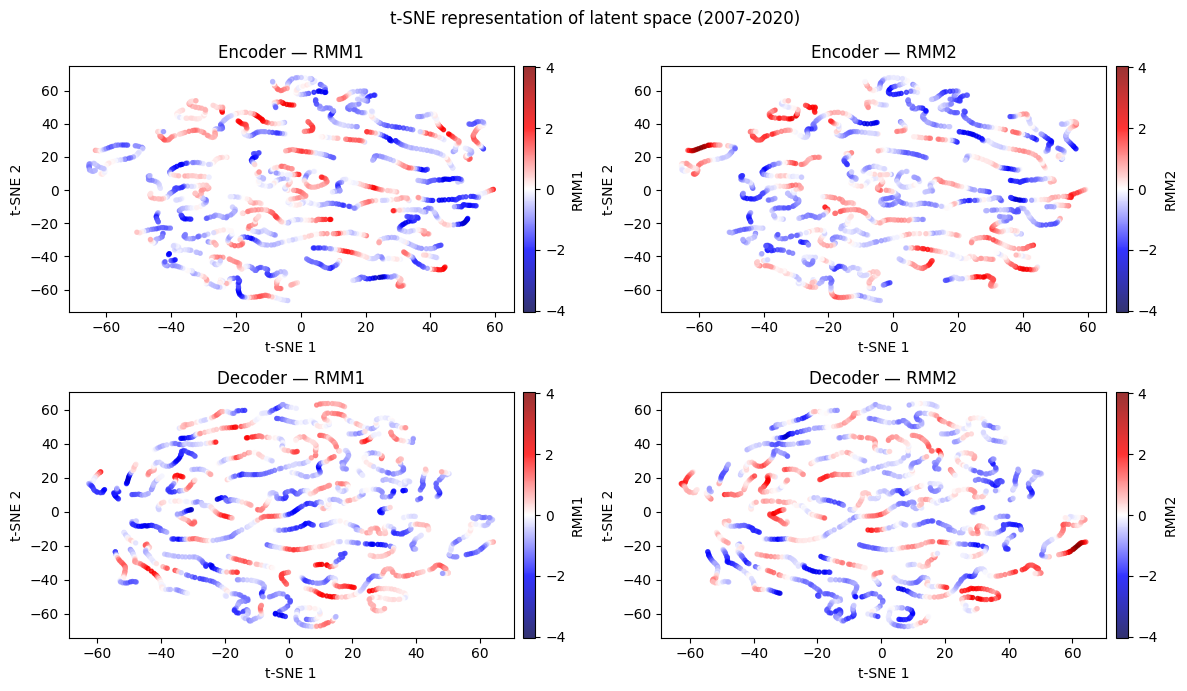

In [8]:
# Encoder vs decoder: separate t-SNE in each space; color by observed RMM / phase.
years_tsne = (2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020)
mask_1820 = np.isin(year_labels, years_tsne)

y1 = y_rmm1[mask_1820]
y2 = y_rmm2[mask_1820]
phase = np.arctan2(y2, y1)


def tsne_2d(X_raw, random_state=66):
    Xs = StandardScaler().fit_transform(X_raw)
    n = Xs.shape[0]
    # perp = min(30, max(5, (n - 1) // 3))
    perp = 20
    return TSNE(
        n_components=2,
        perplexity=perp,
        learning_rate="auto",
        max_iter=1000,
        random_state=random_state,
    ).fit_transform(Xs)


Ze = tsne_2d(latent_array_e[mask_1820])
Zd = tsne_2d(latent_array_d[mask_1820])
# use one common color range for all panels
global_abs = max(
    np.max(np.abs(y1)),
    np.max(np.abs(y2))
)
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
panels = [
    (y1, "seismic", global_abs, "RMM1"),
    (y2, "seismic", global_abs, "RMM2"),
]
for row, (Z, row_name) in enumerate([(Ze, "Encoder"), (Zd, "Decoder")]):
    for col, (c, cmap, vabs, title_suffix) in enumerate(panels):
        ax = axes[row, col]

        sc = ax.scatter(
            Z[:, 0], Z[:, 1],
            c=c,
            cmap=cmap,
            s=8,
            alpha=0.8,
            vmin=-vabs,
            vmax=vabs
        )
        cbar = plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.02)
        cbar.set_label(title_suffix)

        ax.set_title(f"{row_name} — {title_suffix}")
        ax.set_xlabel("t-SNE 1")
        ax.set_ylabel("t-SNE 2")

fig.suptitle("t-SNE representation of latent space (2007-2020)")
plt.tight_layout()
plt.show()

### Visualization of RMM Phase Space, points are colored by tSNE amplitude

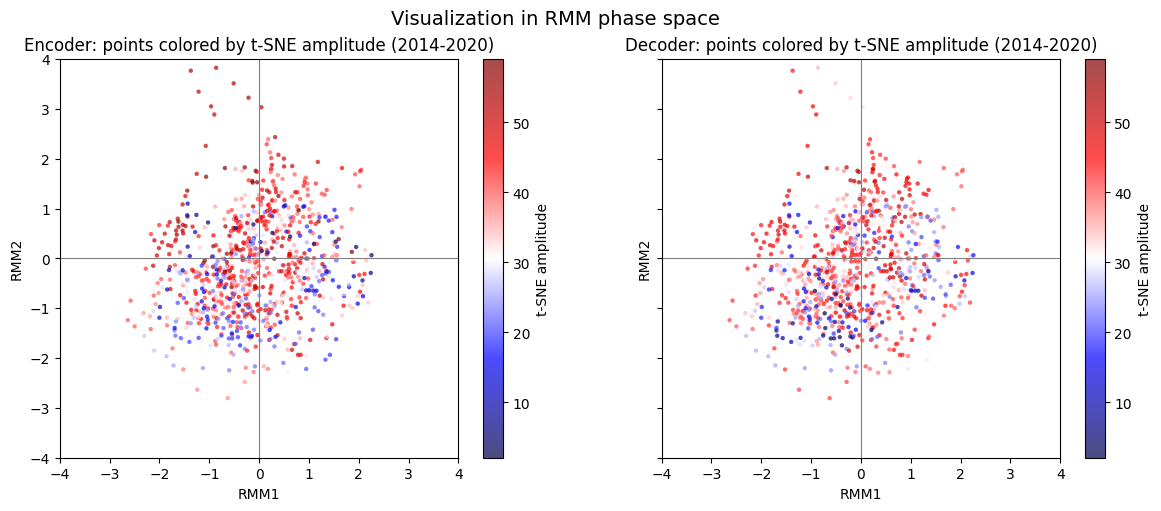

In [202]:
years_tsne = (2014, 2015, 2016, 2017, 2018, 2019, 2020)
mask_14720 = np.isin(year_labels, years_tsne)

rmm1 = y_rmm1[mask_14720]
rmm2 = y_rmm2[mask_14720]
times = pd.to_datetime(latent_times[mask_14720])

def tsne_2d(X_raw, random_state=42):
    Xs = StandardScaler().fit_transform(X_raw)
    n = Xs.shape[0]
    # perp = min(30, max(5, (n - 1) // 3))
    perp = 20
    return TSNE(
        n_components=2,
        perplexity=perp,
        learning_rate="auto",
        random_state=random_state,
    ).fit_transform(Xs)

Ze = tsne_2d(latent_array_e[mask_14720])
Zd = tsne_2d(latent_array_d[mask_14720])

amp_e = np.sqrt(Ze[:, 0]**2 + Ze[:, 1]**2)
amp_d = np.sqrt(Zd[:, 0]**2 + Zd[:, 1]**2)

vmin = min(amp_e.min(), amp_d.min())
vmax = max(amp_e.max(), amp_d.max())

fig, axes = plt.subplots(
    1, 2, figsize=(12, 5),
    sharex=True, sharey=True,
    constrained_layout=True
)

sc1 = axes[0].scatter(
    rmm1, rmm2,
    c=amp_e, cmap="seismic",
    s=10, alpha=0.7,
    vmin=vmin, vmax=vmax,
    edgecolors="none"
)

sc2 = axes[1].scatter(
    rmm1, rmm2,
    c=amp_d, cmap="seismic",
    s=10, alpha=0.7,
    vmin=vmin, vmax=vmax,
    edgecolors="none"
)

titles = [
    "Encoder: points colored by t-SNE amplitude (2014-2020)",
    "Decoder: points colored by t-SNE amplitude (2014-2020)"
]

for ax, title in zip(axes, titles):
    ax.set_title(title, fontsize=12)
    ax.set_xlim(-4, 4)
    ax.set_ylim(-4, 4)
    ax.set_aspect("equal", adjustable="box")
    ax.axhline(0, color="gray", lw=0.8)
    ax.axvline(0, color="gray", lw=0.8)
    ax.set_xlabel("RMM1")
    ax.set_ylabel("RMM2")

cb1 = fig.colorbar(sc1, ax=axes[0], fraction=0.046, pad=0.04)
cb1.set_label("t-SNE amplitude")

cb2 = fig.colorbar(sc2, ax=axes[1], fraction=0.046, pad=0.04)
cb2.set_label("t-SNE amplitude")

fig.suptitle("Visualization in RMM phase space", fontsize=14)
plt.show()

### Year Example Visualization of RMM Phase Space.

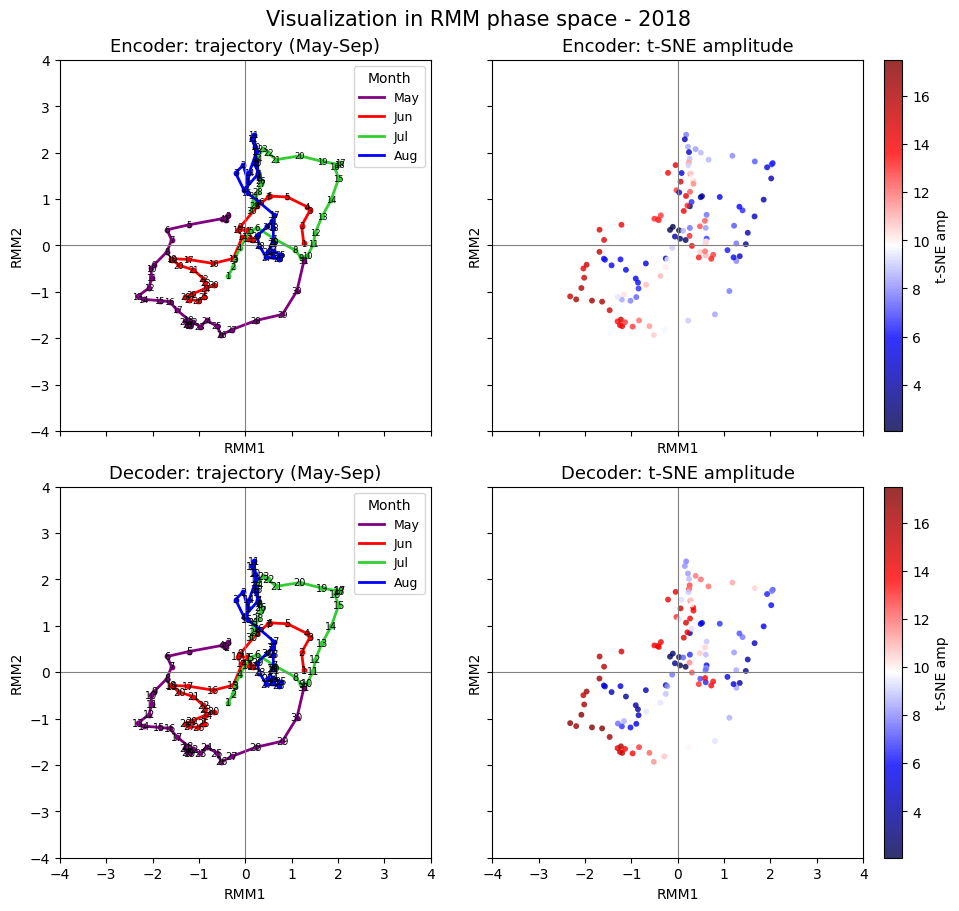

In [204]:
years_tsne = (2018,)
mask_1820 = np.isin(year_labels, years_tsne)

rmm1 = y_rmm1[mask_1820]
rmm2 = y_rmm2[mask_1820]
times = pd.to_datetime(latent_times[mask_1820])

def tsne_2d(X_raw, random_state=42):
    Xs = StandardScaler().fit_transform(X_raw)
    n = Xs.shape[0]
    # perp = min(30, max(5, (n - 1) // 3))
    perp = 30
    return TSNE(
        n_components=2,
        perplexity=perp,
        learning_rate="auto",
        random_state=random_state,
    ).fit_transform(Xs)

Ze = tsne_2d(latent_array_e[mask_1820])
Zd = tsne_2d(latent_array_d[mask_1820])

amp_e = np.sqrt(Ze[:, 0]**2 + Ze[:, 1]**2)
amp_d = np.sqrt(Zd[:, 0]**2 + Zd[:, 1]**2)

month_colors = {
    5: "purple",
    6: "red",
    7: "limegreen",
    8: "blue",
}

month_names = {
    5: "May",
    6: "Jun",
    7: "Jul",
    8: "Aug",
}

fig, axes = plt.subplots(
    2, 2, figsize=(9.5, 9),
    sharex=True, sharey=True,
    constrained_layout=True
)

# top-left: encoder trajectory
for m in [5, 6, 7, 8]:
    idx = np.where(times.month == m)[0]
    if len(idx) == 0:
        continue

    color = month_colors[m]
    day_vals = times[idx].day

    axes[0, 0].plot(
        rmm1[idx], rmm2[idx],
        color=color, lw=2,
        label=month_names[m]
    )
    axes[0, 0].scatter(rmm1[idx], rmm2[idx], color=color, s=10)

    for x, y, d in zip(rmm1[idx], rmm2[idx], day_vals):
        axes[0, 0].text(x, y, str(d), fontsize=6, color="black",
                        ha="center", va="center")

# bottom-left: decoder trajectory
for m in [5, 6, 7, 8]:
    idx = np.where(times.month == m)[0]
    if len(idx) == 0:
        continue

    color = month_colors[m]
    day_vals = times[idx].day

    axes[1, 0].plot(
        rmm1[idx], rmm2[idx],
        color=color, lw=2,
        label=month_names[m]
    )
    axes[1, 0].scatter(rmm1[idx], rmm2[idx], color=color, s=10)

    for x, y, d in zip(rmm1[idx], rmm2[idx], day_vals):
        axes[1, 0].text(x, y, str(d), fontsize=7, color="black",
                        ha="center", va="center")

# right column: points colored by t-SNE amplitude
vmin = min(amp_e.min(), amp_d.min())
vmax = max(amp_e.max(), amp_d.max())

sc1 = axes[0, 1].scatter(
    rmm1, rmm2, c=amp_e, cmap="seismic",
    s=18, alpha=0.8,
    vmin=vmin, vmax=vmax, edgecolors="none"
)

sc2 = axes[1, 1].scatter(
    rmm1, rmm2, c=amp_d, cmap="seismic",
    s=18, alpha=0.8,
    vmin=vmin, vmax=vmax, edgecolors="none"
)

titles = [
    ["Encoder: trajectory (May-Sep)", "Encoder: t-SNE amplitude"],
    ["Decoder: trajectory (May-Sep)", "Decoder: t-SNE amplitude"],
]

for i in range(2):
    for j in range(2):
        ax = axes[i, j]
        ax.set_title(titles[i][j], fontsize=13)
        ax.set_xlim(-4, 4)
        ax.set_ylim(-4, 4)
        ax.set_aspect("equal", adjustable="box")
        ax.axhline(0, color="gray", lw=0.8)
        ax.axvline(0, color="gray", lw=0.8)
        ax.set_xlabel("RMM1")
        ax.set_ylabel("RMM2")

axes[0, 0].legend(title="Month", loc="upper right", fontsize=9)
axes[1, 0].legend(title="Month", loc="upper right", fontsize=9)

cb1 = fig.colorbar(sc1, ax=axes[0, 1], fraction=0.046, pad=0.04)
cb1.set_label("t-SNE amp")

cb2 = fig.colorbar(sc2, ax=axes[1, 1], fraction=0.046, pad=0.04)
cb2.set_label("t-SNE amp")

fig.suptitle(f"Visualization in RMM phase space - {years_tsne[0]}", fontsize=15)
plt.show()

### TSNE for SST

In [206]:
sst_may_aug = sst_ssta[
    (sst_ssta.index.year >= 2014) &
    (sst_ssta.index.year <= 2020) &
    (sst_ssta.index.month >= 5) &
    (sst_ssta.index.month <= 8)
]

print("SST weekly range:", sst_may_aug.index.min(), "->", sst_may_aug.index.max())
print("Number of weekly samples:", len(sst_may_aug))
print("NaN count after interpolation:", sst_may_aug.isna().sum())
print()
print(sst_may_aug.head())
print("...")
print(sst_may_aug.tail())

SST weekly range: 2014-05-07 00:00:00 -> 2020-08-26 00:00:00
Number of weekly samples: 123
NaN count after interpolation: 0

2014-05-07    0.4
2014-05-14    0.3
2014-05-21    0.6
2014-05-28    0.6
2014-06-04    0.5
Name: nino34_ssta, dtype: float32
...
2020-07-29   -0.4
2020-08-05   -0.6
2020-08-12   -0.6
2020-08-19   -0.5
2020-08-26   -0.5
Name: nino34_ssta, dtype: float32


In [207]:
latent_dates = pd.to_datetime(latent_times).normalize()
latent_df_e = pd.DataFrame(latent_array_e, index=latent_dates)
latent_df_d = pd.DataFrame(latent_array_d, index=latent_dates)
latent_df_e = latent_df_e[
    (latent_df_e.index.year >= 2014) &
    (latent_df_e.index.year <= 2020)
]
latent_df_d = latent_df_d[
    (latent_df_d.index.year >= 2014) &
    (latent_df_d.index.year <= 2020)
]
sst_may_aug.index = pd.to_datetime(sst_may_aug.index).normalize()
common_idx = sst_may_aug.index.intersection(latent_df_e.index).intersection(latent_df_d.index)
X_e_sst = latent_df_e.loc[common_idx]
X_d_sst = latent_df_d.loc[common_idx]
y_sst = sst_may_aug.loc[common_idx]
print("Matched weekly SST samples:", len(common_idx))
print("Matched range:", common_idx.min(), "->", common_idx.max())
print("Encoder matched shape:", X_e_sst.shape)
print("Decoder matched shape:", X_d_sst.shape)
print("SST matched shape:", y_sst.shape)

Matched weekly SST samples: 123
Matched range: 2014-05-07 00:00:00 -> 2020-08-26 00:00:00
Encoder matched shape: (123, 2560)
Decoder matched shape: (123, 2560)
SST matched shape: (123,)


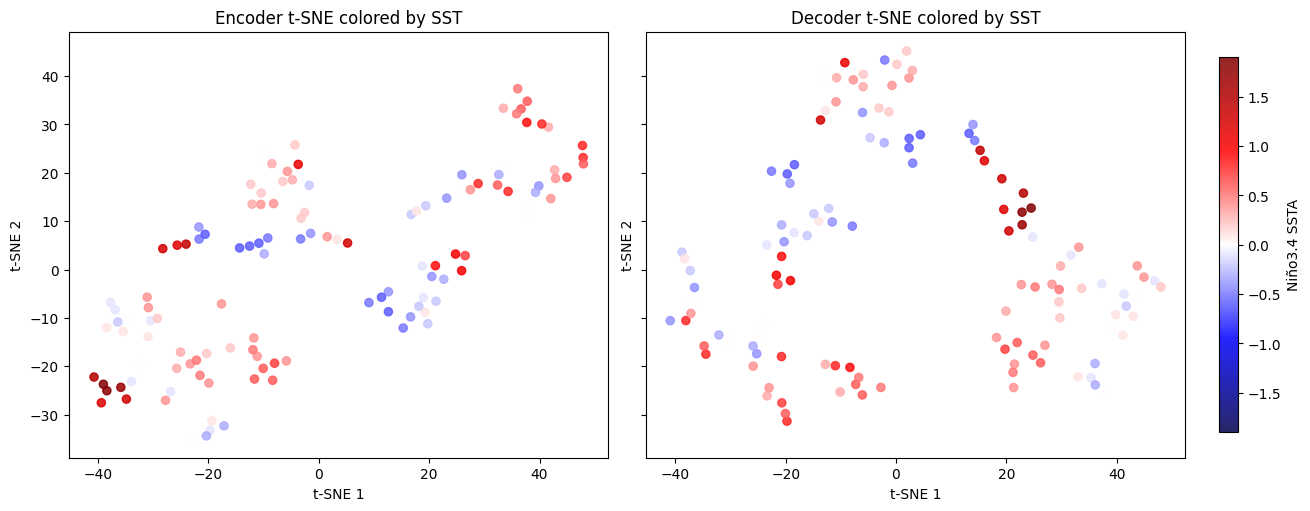

In [208]:
def tsne_2d_sst(X, perplexity=20, random_state=42):
    X_scaled = StandardScaler().fit_transform(X)
    Z = TSNE(
        n_components=2,
        perplexity=perplexity,
        learning_rate="auto",
        init="pca",
        max_iter=1000,
        random_state=random_state
    ).fit_transform(X_scaled)
    return Z

Ze_sst = tsne_2d_sst(X_e_sst.values, perplexity=5, random_state=42)
Zd_sst = tsne_2d_sst(X_d_sst.values, perplexity=5, random_state=42)

y_vals = y_sst.values if hasattr(y_sst, "values") else y_sst
vabs = np.max(np.abs(y_vals))

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True, sharey=True, constrained_layout=True)

sc1 = axes[0].scatter(
    Ze_sst[:, 0], Ze_sst[:, 1],
    c=y_vals,
    cmap="seismic",
    s=35,
    alpha=0.85,
    vmin=-vabs,
    vmax=vabs
)
axes[0].set_title("Encoder t-SNE colored by SST")
axes[0].set_xlabel("t-SNE 1")
axes[0].set_ylabel("t-SNE 2")

sc2 = axes[1].scatter(
    Zd_sst[:, 0], Zd_sst[:, 1],
    c=y_vals,
    cmap="seismic",
    s=35,
    alpha=0.85,
    vmin=-vabs,
    vmax=vabs
)
axes[1].set_title("Decoder t-SNE colored by SST")
axes[1].set_xlabel("t-SNE 1")
axes[1].set_ylabel("t-SNE 2")

cbar = fig.colorbar(sc2, ax=axes, location="right", shrink=0.88, pad=0.03)
cbar.set_label("Niño3.4 SSTA")

plt.show()